# iResNet50 + ArcFace — One-Shot Face Recognition (MS1M Dataset)

Train iResNet50 backbone with ArcFace loss on **dataset_ms1m** (~79K identities, ~5.4M images).

**Key fixes applied:**
- `start_step` double-count bug in LR schedule fixed
- Checkpoint integrity verified before restore
- LR correctly logged in training history

**Outputs** → `models/face_recognition/iresnet/results_iresnet50/`:
- `best_iresnet50_backbone.h5` — backbone for inference / one-shot verification
- `best_iresnet50.h5` — full training model weights
- `training_history.png` — loss/accuracy/LR/margin charts
- `training_meta.json` — full epoch-by-epoch history
- `checkpoints/latest/` — last 2 checkpoints (resume)
- `checkpoints/best/` — best val_accuracy checkpoint
- `verification_roc.png`, `verification_distribution.png` — eval on unseen test identities

---
## 1. Project Root & GPU Init

In [1]:
import os, sys, json
import tensorflow as tf

# Project root
PROJECT_ROOT = r"C:\Users\Admin\Desktop\Project_DAT301m"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

# GPU config
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.keras.backend.clear_session()
    print(f"[GPU] {len(gpus)} GPU(s) detected. Memory growth ON.")
else:
    print("[GPU] No GPU found. Running on CPU.")

Project root: C:\Users\Admin\Desktop\Project_DAT301m
[GPU] 1 GPU(s) detected. Memory growth ON.


---
## 2. Configuration

**ArcFace Paper Config (Deng et al., 2019) adapted for MS1M:**
- Optimizer: SGD(lr=0.01, momentum=0.9, nesterov=True, weight_decay=5e-4)
- LR Schedule: Step Decay at [16, 22, 26, 30], gamma=0.1
- Progressive Margin: 0.1 → 0.5 (step +0.1 every 5 epochs)
- Scale s=64.0, Label Smoothing=0.1, Dropout=0.5
- Input: 112x112, Embedding: 512-D, Batch: 128

In [2]:
# ── Configuration ──────────────────────────
CONFIG = {
    # Data paths (MS1M-ArcFace dataset — train/val share identities)
    "dataset_dir": "ms1m_arcface_dataset/train",
    "val_dir":     "ms1m_arcface_dataset/val",
    "test_dir":    "ms1m_arcface_dataset/test",

    # Training
    "loss_type":        "arcface",      # arcface | cosface | sphereface | softmax
    "epochs":           25,
    "batch_size":       128,
    "img_size":         112,
    "embedding_dim":    512,
    "dropout":          0.5,            # ArcFace paper: 0.5
    "lr":               0.01,           # SGD initial LR
    "weight_decay":     5e-4,           # L2 weight decay
    "arcface_scale":    64.0,           # Scale factor s
    "label_smoothing":  0.1,            # Label smoothing for generalization
    "patience":         15,             # Early stopping patience
    "warmup_epochs":    2,              # Linear LR warmup
    "clipnorm":         1.0,            # Gradient clipping (0=disable)

    # LR Schedule (Step Decay per ArcFace paper)
    "milestones":       "5,8,10,12", # LR decay at these epochs
    "gamma":            0.1,            # Decay factor

    # Progressive Margin Schedule
    "margin_step":       0.1,           # +0.1 rad margin per step
    "margin_step_every": 5,             # Every 5 epochs

    # Verification evaluation
    "verify_every":      3,             # Evaluate every N epochs
    "verify_pairs":      5000,          # Pairs for verification

    # Resume (set True to continue from checkpoint)
    "resume":            True,
}

# ── Print summary ──
print(f"Configuration [{CONFIG['loss_type'].upper()} mode]")
print(f"  Dataset:    {CONFIG['dataset_dir']} ({76504} shared train/val classes)")
print(f"  Val:        {CONFIG['val_dir']}")
print(f"  Test:       {CONFIG['test_dir']} ({8500} unseen identities)")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Epochs:     {CONFIG['epochs']}")
print(f"  LR:         {CONFIG['lr']} (SGD + step decay)")
print(f"  Resume:     {CONFIG['resume']}")

Configuration [ARCFACE mode]
  Dataset:    ms1m_arcface_dataset/train (76504 shared train/val classes)
  Val:        ms1m_arcface_dataset/val
  Test:       ms1m_arcface_dataset/test (8500 unseen identities)
  Batch size: 128
  Epochs:     25
  LR:         0.01 (SGD + step decay)
  Resume:     True


import importlib, os
from models.face_recognition.iresnet import train
importlib.reload(train)
from models.face_recognition.iresnet.train import main as train_main

# Results directory
RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Build argument list from CONFIG
sys.argv = [
    'train.py',
    '--dataset_dir',    CONFIG['dataset_dir'],
    '--val_dir',        CONFIG['val_dir'],
    '--test_dir',       CONFIG['test_dir'],
    '--results_dir',    RESULTS_DIR,
    '--loss_type',      CONFIG['loss_type'],
    '--epochs',         str(CONFIG['epochs']),
    '--batch_size',     str(CONFIG['batch_size']),
    '--img_size',       str(CONFIG['img_size']),
    '--embedding_dim',  str(CONFIG['embedding_dim']),
    '--dropout',        str(CONFIG['dropout']),
    '--lr',             str(CONFIG['lr']),
    '--weight_decay',   str(CONFIG['weight_decay']),
    '--arcface_scale',  str(CONFIG['arcface_scale']),
    '--label_smoothing',str(CONFIG['label_smoothing']),
    '--patience',       str(CONFIG['patience']),
    '--warmup_epochs',  str(CONFIG['warmup_epochs']),
    '--clipnorm',       str(CONFIG['clipnorm']),
    '--milestones',     CONFIG['milestones'],
    '--gamma',          str(CONFIG['gamma']),
    '--margin_step',     str(CONFIG['margin_step']),
    '--margin_step_every', str(CONFIG['margin_step_every']),
    '--verify_every',   str(CONFIG['verify_every']),
    '--verify_pairs',   str(CONFIG['verify_pairs']),
]

if CONFIG['resume']:
    sys.argv.append('--resume')

print(f"\nStarting {CONFIG['loss_type'].upper()} training on MS1M...")
print(f"Results -> {RESULTS_DIR}/")
print("=" * 60)

train_main()

print("\n" + "=" * 60)
print(f"Training done. Check {RESULTS_DIR}/")

In [3]:
import importlib, os
from models.face_recognition.iresnet import train
importlib.reload(train)
from models.face_recognition.iresnet.train import main as train_main

# Results directory
RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Build argument list from CONFIG
sys.argv = [
    'train.py',
    '--dataset_dir',    CONFIG['dataset_dir'],
    '--val_dir',        CONFIG['val_dir'],
    '--test_dir',       CONFIG['test_dir'],
    '--results_dir',    RESULTS_DIR,
    '--loss_type',      CONFIG['loss_type'],
    '--epochs',         str(CONFIG['epochs']),
    '--batch_size',     str(CONFIG['batch_size']),
    '--img_size',       str(CONFIG['img_size']),
    '--embedding_dim',  str(CONFIG['embedding_dim']),
    '--dropout',        str(CONFIG['dropout']),
    '--lr',             str(CONFIG['lr']),
    '--weight_decay',   str(CONFIG['weight_decay']),
    '--arcface_scale',  str(CONFIG['arcface_scale']),
    '--label_smoothing',str(CONFIG['label_smoothing']),
    '--patience',       str(CONFIG['patience']),
    '--warmup_epochs',  str(CONFIG['warmup_epochs']),
    '--clipnorm',       str(CONFIG['clipnorm']),
    '--milestones',     CONFIG['milestones'],
    '--gamma',          str(CONFIG['gamma']),
    '--margin_step',     str(CONFIG['margin_step']),
    '--margin_step_every', str(CONFIG['margin_step_every']),
    '--verify_every',   str(CONFIG['verify_every']),
    '--verify_pairs',   str(CONFIG['verify_pairs']),
]

if CONFIG['resume']:
    sys.argv.append('--resume')

print(f"\nStarting {CONFIG['loss_type'].upper()} training on MS1M...")
print(f"Results -> {RESULTS_DIR}/")
print("=" * 60)

train_main()

print("\n" + "=" * 60)
print(f"Training done. Check {RESULTS_DIR}/")


Starting ARCFACE training on MS1M...
Results -> models/face_recognition/iresnet/results_iresnet50/
[GPU] Memory Growth enabled. 1 GPU(s) detected.
[Data] Loaded 4748639 train images, 491516 val images across 76504 classes.
✓ Checkpoint files verified: models/face_recognition/iresnet/results_iresnet50\checkpoints\latest\ckpt-17
[Resume] Full checkpoint found: models/face_recognition/iresnet/results_iresnet50\checkpoints\latest\ckpt-17
Model: "IRESNET50_Backbone"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 112, 112, 3  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv (Conv2D)             (None,

KeyboardInterrupt: 

from models.face_recognition.iresnet.iresnet50 import iResNet_Backbone

RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"

backbone = iResNet_Backbone(
    input_shape=(112, 112, 3),
    embedding_dim=512,
    dropout_rate=CONFIG['dropout'],
    normalize_embeddings=True,
)
backbone.load_weights(f"{RESULTS_DIR}/best_iresnet50_backbone.h5")
print(f"[OK] Best backbone loaded from {RESULTS_DIR}/")
print(f"  Params: {backbone.count_params():,}")

In [ ]:
from models.face_recognition.iresnet.iresnet50 import iResNet_Backbone

RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"

backbone = iResNet_Backbone(
    input_shape=(112, 112, 3),
    embedding_dim=512,
    dropout_rate=CONFIG['dropout'],
    normalize_embeddings=True,
)
backbone.load_weights(f"{RESULTS_DIR}/best_iresnet50_backbone.h5")
print(f"[OK] Best backbone loaded from {RESULTS_DIR}/")
print(f"  Params: {backbone.count_params():,}")

[OK] Best backbone loaded from models/face_recognition/iresnet/results_iresnet50/
  Params: 43,628,480


import os, glob

def check_ckpt_dir(ckpt_dir, label):
    """Verify checkpoint files exist and are consistent."""
    print(f"\n[{label}] {ckpt_dir}")
    if not os.path.isdir(ckpt_dir):
        print("  (directory does not exist)")
        return
    
    # Find checkpoint prefix
    data_files = sorted(glob.glob(os.path.join(ckpt_dir, "*.data-00000-of-00001")))
    index_files = sorted(glob.glob(os.path.join(ckpt_dir, "*.index")))
    
    for df in data_files:
        prefix = df.replace(".data-00000-of-00001", "")
        idx_file = prefix + ".index"
        size_mb = os.path.getsize(df) / (1024 * 1024)
        has_idx = os.path.exists(idx_file)
        status = "OK" if has_idx else "MISSING INDEX"
        print(f"  {os.path.basename(prefix)}: {size_mb:.0f} MB [{status}]")
    
    if not data_files:
        print("  (no checkpoint data files found)")

RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
check_ckpt_dir(os.path.join(RESULTS_DIR, "checkpoints", "latest"), "iResNet Latest")
check_ckpt_dir(os.path.join(RESULTS_DIR, "checkpoints", "best"), "iResNet Best")

# Also check Siamese checkpoints
SIAMESE_DIR = "models/face_recognition/siamese/results"
print(f"\n{'='*60}")
print("Siamese Checkpoints")
check_ckpt_dir(os.path.join(SIAMESE_DIR, "checkpoints", "latest"), "Siamese Latest")
check_ckpt_dir(os.path.join(SIAMESE_DIR, "checkpoints", "best"), "Siamese Best")

# Check meta files
for d, label in [(RESULTS_DIR, "iResNet"), (SIAMESE_DIR, "Siamese")]:
    meta_path = os.path.join(d, "training_meta.json")
    if os.path.exists(meta_path):
        with open(meta_path, "r") as f:
            meta = json.load(f)
        print(f"\n[{label} Meta]")
        print(f"  Last epoch:     {meta.get('last_epoch', 'N/A')}")
        print(f"  Next epoch:     {meta.get('next_epoch', 'N/A')}")
        print(f"  Best val_acc:   {meta.get('best_val_accuracy', 'N/A')}")
        print(f"  Current margin: {meta.get('current_margin', 'N/A')}")
        print(f"  Current LR:     {meta.get('current_lr', 'N/A')}")
        print(f"  Num classes:    {meta.get('num_classes', 'N/A')}")
        if 'history' in meta:
            h = meta['history']
            print(f"  History epochs: {len(h.get('train_loss', []))}")
    else:
        print(f"\n[{label} Meta] (no training_meta.json)")

In [ ]:
import os, glob

def check_ckpt_dir(ckpt_dir, label):
    """Verify checkpoint files exist and are consistent."""
    print(f"\n[{label}] {ckpt_dir}")
    if not os.path.isdir(ckpt_dir):
        print("  (directory does not exist)")
        return
    
    # Find checkpoint prefix
    data_files = sorted(glob.glob(os.path.join(ckpt_dir, "*.data-00000-of-00001")))
    index_files = sorted(glob.glob(os.path.join(ckpt_dir, "*.index")))
    
    for df in data_files:
        prefix = df.replace(".data-00000-of-00001", "")
        idx_file = prefix + ".index"
        size_mb = os.path.getsize(df) / (1024 * 1024)
        has_idx = os.path.exists(idx_file)
        status = "OK" if has_idx else "MISSING INDEX"
        print(f"  {os.path.basename(prefix)}: {size_mb:.0f} MB [{status}]")
    
    if not data_files:
        print("  (no checkpoint data files found)")

RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
check_ckpt_dir(os.path.join(RESULTS_DIR, "checkpoints", "latest"), "Latest Checkpoints")
check_ckpt_dir(os.path.join(RESULTS_DIR, "checkpoints", "best"), "Best Checkpoint")

# Also check Siamese checkpoints
SIAMESE_DIR = "models/face_recognition/siamese/results"
print(f"\n{'='*60}")
print("Siamese Checkpoints")
check_ckpt_dir(os.path.join(SIAMESE_DIR, "checkpoints", "latest"), "Latest Checkpoints")
check_ckpt_dir(os.path.join(SIAMESE_DIR, "checkpoints", "best"), "Best Checkpoint")

# Check meta files
for d, label in [(RESULTS_DIR, "iResNet"), (SIAMESE_DIR, "Siamese")]:
    meta_path = os.path.join(d, "training_meta.json")
    if os.path.exists(meta_path):
        with open(meta_path, "r") as f:
            meta = json.load(f)
        print(f"\n[{label} Meta]")
        print(f"  Last epoch:     {meta.get('last_epoch', 'N/A')}")
        print(f"  Next epoch:     {meta.get('next_epoch', 'N/A')}")
        print(f"  Best val_acc:   {meta.get('best_val_accuracy', 'N/A')}")
        print(f"  Current margin: {meta.get('current_margin', 'N/A')}")
        print(f"  Current LR:     {meta.get('current_lr', 'N/A')}")
        print(f"  Num classes:    {meta.get('num_classes', 'N/A')}")
        if 'history' in meta:
            h = meta['history']
            print(f"  History epochs: {len(h.get('train_loss', []))}")
    else:
        print(f"\n[{label} Meta] (no training_meta.json)")


[Latest Checkpoints] models/face_recognition/iresnet/results_iresnet50\checkpoints\latest
  ckpt-6: 632 MB [OK]
  ckpt-7: 632 MB [OK]

[Best Checkpoint] models/face_recognition/iresnet/results_iresnet50\checkpoints\best
  ckpt-5: 632 MB [OK]

Siamese Checkpoints

[Latest Checkpoints] models/face_recognition/siamese/results\checkpoints\latest
  ckpt-1: 500 MB [OK]
  ckpt-2: 500 MB [OK]

[Best Checkpoint] models/face_recognition/siamese/results\checkpoints\best
  ckpt-2: 500 MB [OK]

[iResNet Meta]
  Last epoch:     6
  Next epoch:     7
  Best val_acc:   0.919811487197876
  Current margin: 0.20000000298023224
  Current LR:     0.0010000000474974513
  Num classes:    76504
  History epochs: 7

[Siamese Meta]
  Last epoch:     1
  Next epoch:     2
  Best val_acc:   N/A
  Current margin: N/A
  Current LR:     N/A
  Num classes:    N/A


import numpy as np
from shared.face_preprocessing import preprocess_face

def get_embedding(backbone, img_path):
    """Extract L2-normalized 512-D embedding from a face image."""
    img = preprocess_face(img_path)
    emb = backbone.predict(img, verbose=0)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    return emb.flatten()

# Load backbone
RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
backbone = iResNet_Backbone(
    input_shape=(112, 112, 3), embedding_dim=512,
    dropout_rate=CONFIG['dropout'], normalize_embeddings=True,
)
backbone.load_weights(f"{RESULTS_DIR}/best_iresnet50_backbone.h5")

# Test on one-shot pairs
test_dir = r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot"
anchor_path = os.path.join(test_dir, "origin.jpg")
query_paths = [
    os.path.join(test_dir, f"test{i}.jpg") for i in range(1, 14)
    if os.path.exists(os.path.join(test_dir, f"test{i}.jpg"))
]

anchor_emb = get_embedding(backbone, anchor_path)
print(f"Anchor: origin.jpg")
print(f"{'Query':<20} {'Cosine':>8} {'Match?':>8}")
print("-" * 40)

threshold = 0.40  # Standard ArcFace threshold
for qp in query_paths:
    q_emb = get_embedding(backbone, qp)
    cos_sim = float(np.dot(anchor_emb, q_emb))
    match = "YES" if cos_sim > threshold else "NO"
    print(f"{os.path.basename(qp):<20} {cos_sim:>8.4f} {match:>8}")

In [ ]:
import numpy as np
from shared.face_preprocessing import preprocess_face

def get_embedding(backbone, img_path):
    """Extract L2-normalized 512-D embedding from a face image."""
    img = preprocess_face(img_path)
    emb = backbone.predict(img, verbose=0)
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    return emb.flatten()

# Load backbone
RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
backbone = iResNet_Backbone(
    input_shape=(112, 112, 3), embedding_dim=512,
    dropout_rate=CONFIG['dropout'], normalize_embeddings=True,
)
backbone.load_weights(f"{RESULTS_DIR}/best_iresnet50_backbone.h5")

# Test on one-shot pairs
test_dir = r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot"
anchor_path = os.path.join(test_dir, "origin.jpg")
query_paths = [
    os.path.join(test_dir, f"test{i}.jpg") for i in range(1, 14)
    if os.path.exists(os.path.join(test_dir, f"test{i}.jpg"))
]

query_paths.append(os.path.join(test_dir, f"test5.png"))
anchor_emb = get_embedding(backbone, anchor_path)
print(f"Anchor: origin.jpg")
print(f"{'Query':<20} {'Cosine':>8} {'Match?':>8}")
print("-" * 40)

threshold = 0.57  # Standard ArcFace threshold
for qp in query_paths:
    q_emb = get_embedding(backbone, qp)
    cos_sim = float(np.dot(anchor_emb, q_emb))
    match = "YES" if cos_sim > threshold else "NO"
    print(f"{os.path.basename(qp):<20} {cos_sim:>8.4f} {match:>8}")

Anchor: origin.jpg
Query                  Cosine   Match?
----------------------------------------
test1.jpg              0.4570       NO
test2.jpg              0.5881      YES
test3.jpg              0.7765      YES
test4.jpg              0.4876       NO
test6.jpg              0.3510       NO
test7.jpg              0.2879       NO
test8.jpg              0.4647       NO
test9.jpg              0.2271       NO
test10.jpg             0.5826      YES
test11.jpg             0.4954       NO
test12.jpg             0.2226       NO
test13.jpg             0.4726       NO
test5.png              0.6415      YES


---
## 7. Manual Verification + t-SNE (Run after training)

Load backbone đã save, trích xuất embedding trên test identities, visualize t-SNE + ROC + Distribution.

In [ ]:
# ── Scan test identities + Extract embeddings (SUBSET) ──
from pathlib import Path
from shared.face_preprocessing import preprocess_face
import random as _random

RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
TEST_DIR = Path("ms1m_arcface_dataset/test")

# Scan
id_to_imgs = {}
for d in sorted(TEST_DIR.iterdir()):
    if d.is_dir():
        imgs = [str(p) for p in d.iterdir() if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}]
        if len(imgs) >= 2:
            id_to_imgs[d.name] = imgs
all_identities = list(id_to_imgs.keys())
total_imgs = sum(len(v) for v in id_to_imgs.values())
print(f"Test full: {len(all_identities)} identities, {total_imgs} images")

# Pick subset: 500 identities, up to 10 images each = max 5000 images
MAX_IDS, MAX_PER_ID = 500, 10
rng = _random.Random(42)
picked = rng.sample(all_identities, min(MAX_IDS, len(all_identities)))
identities = picked

all_paths, all_labels = [], []
for i, ident in enumerate(identities):
    imgs = id_to_imgs[ident]
    if len(imgs) > MAX_PER_ID:
        imgs = rng.sample(imgs, MAX_PER_ID)
    all_paths.extend(imgs)
    all_labels.extend([i] * len(imgs))
all_labels = np.array(all_labels)
print(f"Subset: {len(identities)} identities, {len(all_paths)} images")

# Load backbone
from models.face_recognition.iresnet.iresnet50 import iResNet_Backbone
backbone = iResNet_Backbone(
    input_shape=(112, 112, 3), embedding_dim=512,
    dropout_rate=CONFIG['dropout'], normalize_embeddings=True,
)
backbone.load_weights(f"{RESULTS_DIR}/best_iresnet50_backbone.h5")
print(f"Backbone: {backbone.count_params():,} params")

# Extract embeddings (streaming)
all_embs = np.zeros((len(all_paths), 512), dtype=np.float32)
BATCH = 256
print(f"Extracting {len(all_paths)} embeddings...")
for start in range(0, len(all_paths), BATCH):
    end = min(start + BATCH, len(all_paths))
    batch_imgs = np.stack([preprocess_face(p) for p in all_paths[start:end]])
    batch_imgs = batch_imgs.squeeze(1)
    embs = backbone.predict(batch_imgs, verbose=0)
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    all_embs[start:end] = embs / np.maximum(norms, 1e-12)
    if end % 5000 < BATCH:
        print(f"  {end}/{len(all_paths)}")
print(f"Done: {all_embs.shape}")

Test full: 8500 identities, 580011 images
Subset: 500 identities, 4939 images
Backbone: 43,628,480 params
Extracting 4939 embeddings...
[WARN] No face detected in ms1m_arcface_dataset\test\44374\3117211.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\15093\1196953.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\52500\3645204.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\34286\2455507.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\34286\2455510.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\16944\1325420.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\29499\2144532.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\21101\1599522.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\52515\3646355.jpg, using center-crop
[WARN] No face detected in ms1m_arcface_dataset\test\4

In [ ]:
# ── t-SNE visualization ──
from sklearn.manifold import TSNE
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

MAX_IDS, MAX_PER_ID = 30, 10
rng = _random.Random(42)
picked_ids = rng.sample(range(len(identities)), min(MAX_IDS, len(identities)))

tsne_idx, tsne_labels_ids = [], []
for pid in picked_ids:
    mask = np.where(all_labels == pid)[0]
    if len(mask) > MAX_PER_ID:
        mask = rng.sample(list(mask), MAX_PER_ID)
    tsne_idx.extend(mask)
    tsne_labels_ids.extend([pid] * len(mask))

tsne_embs = all_embs[tsne_idx]
tsne_labels_ids = np.array(tsne_labels_ids)
print(f"t-SNE: {len(tsne_idx)} images from {len(picked_ids)} identities")

tsne = TSNE(n_components=2, perplexity=min(30, len(tsne_idx)-1),
            random_state=42, max_iter=1000)
tsne_2d = tsne.fit_transform(tsne_embs)

fig, ax = plt.subplots(figsize=(14, 10))
cmap = plt.cm.tab20
for i, pid in enumerate(sorted(set(tsne_labels_ids))):
    mask = tsne_labels_ids == pid
    ax.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1],
               c=[cmap(i % 20)], label=identities[pid][:15],
               s=30, alpha=0.8, edgecolors='k', linewidth=0.3)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=6)
ax.set_title(f"t-SNE — iResNet50 ArcFace — {len(picked_ids)} unseen identities")
tsne_path = f"{RESULTS_DIR}/verification_tsne.png"
fig.savefig(tsne_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Saved: {tsne_path}")

t-SNE: 300 images from 30 identities
Saved: models/face_recognition/iresnet/results_iresnet50/verification_tsne.png


In [ ]:
# ── Verification: Pairs + ROC + Distribution ──
from shared.eval_verification import compute_roc, compute_auc, compute_eer, plot_roc, plot_score_distribution
from sklearn.metrics import accuracy_score

NUM_PAIRS = 3000
rng = _random.Random(42)

pos_scores, neg_scores = [], []
for _ in range(NUM_PAIRS):
    pid = rng.choice(picked_ids)
    mask = np.where(all_labels == pid)[0]
    if len(mask) >= 2:
        a, b = rng.sample(list(mask), 2)
        pos_scores.append(float(np.dot(all_embs[a], all_embs[b])))

for _ in range(NUM_PAIRS):
    pid1, pid2 = rng.sample(picked_ids, 2)
    a = rng.choice(np.where(all_labels == pid1)[0])
    b = rng.choice(np.where(all_labels == pid2)[0])
    neg_scores.append(float(np.dot(all_embs[a], all_embs[b])))

pos_scores = np.array(pos_scores)
neg_scores = np.array(neg_scores)
scores = np.concatenate([pos_scores, neg_scores])
y_true = np.array([1]*len(pos_scores) + [0]*len(neg_scores))

eer, thresh = compute_eer(y_true, scores)
acc = accuracy_score(y_true, (scores >= thresh).astype(int))
fprs, tprs, _ = compute_roc(y_true, scores)
auc = compute_auc(fprs, tprs)

print(f"Pos mean: {pos_scores.mean():.4f}  |  Neg mean: {neg_scores.mean():.4f}")
print(f"Separation: {pos_scores.mean() - neg_scores.mean():.4f}")
print(f"EER: {eer*100:.2f}%  |  Acc: {acc*100:.2f}%  |  AUC: {auc:.4f}")

roc_path = f"{RESULTS_DIR}/verification_roc.png"
dist_path = f"{RESULTS_DIR}/verification_distribution.png"
plot_roc(fprs, tprs, eer, auc, roc_path)
print(f"Saved: {roc_path}")
plot_score_distribution(pos_scores, neg_scores, dist_path)
print(f"Saved: {dist_path}")

Pos mean: 0.4617  |  Neg mean: 0.1151
Separation: 0.3466
EER: 13.13%  |  Acc: 86.90%  |  AUC: 0.9487
[Plot] ROC curve saved to: models/face_recognition/iresnet/results_iresnet50/verification_roc.png
Saved: models/face_recognition/iresnet/results_iresnet50/verification_roc.png
[Plot] Score distribution saved to: models/face_recognition/iresnet/results_iresnet50/verification_distribution.png
Saved: models/face_recognition/iresnet/results_iresnet50/verification_distribution.png


---
## 8. Multi-Anchor Verification (Few-Shot)

Chọn 3 ảnh làm anchor. Đưa ảnh mới vào → tính cosine similarity với từng anchor → lấy trung bình → quyết định match/no-match.

Backbone loaded: 43,628,480 params

query_emb shape: (512,)


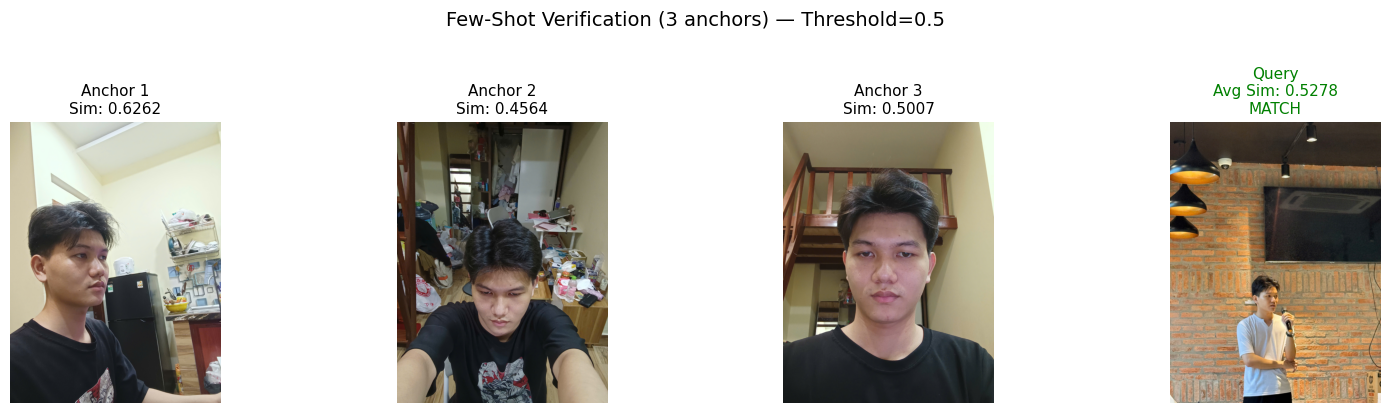

Individual similarities: ['0.6262', '0.4564', '0.5007']
Average: 0.5278 | Threshold: 0.5 | Result: MATCH


In [ ]:
# ── Multi-Anchor Few-Shot Verification (self-contained) ──
import os, sys, numpy as np
PROJECT = r"C:\Users\Admin\Desktop\Project_DAT301m"
os.chdir(PROJECT)
sys.path.insert(0, PROJECT)

import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

from models.face_recognition.iresnet.iresnet50 import iResNet_Backbone
from shared.face_preprocessing import preprocess_face
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

# Load backbone
RESULTS_DIR = "models/face_recognition/iresnet/results_iresnet50"
backbone = iResNet_Backbone(
    input_shape=(112, 112, 3), embedding_dim=512,
    dropout_rate=0.5, normalize_embeddings=True,
)
backbone.load_weights(f"{RESULTS_DIR}/best_iresnet50_backbone.h5")
#backbone.load_weights(f"{RESULTS_DIR}/backbones/backbone_epoch17.h5")
print(f"Backbone loaded: {backbone.count_params():,} params\n")

def get_emb(img_path):
    """Extract flattened L2-normalized 512-D embedding."""
    img = preprocess_face(img_path)           # (1, 112, 112, 3)
    emb = backbone.predict(img, verbose=0)    # (1, 512)
    emb = emb.flatten()                       # (512,)
    return emb / (np.linalg.norm(emb) + 1e-12)

# ── Set your images here ──
ANCHOR_PATHS = [
    r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test1.jpg",
    r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test2.jpg",
    r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\origin.jpg",
]
QUERY_PATH = r"C:\Users\Admin\Desktop\Project_DAT301m\test_one_shot\test13.jpg"
THRESHOLD = 0.5

# Compute embeddings
anchor_embs = [get_emb(ap) for ap in ANCHOR_PATHS]
query_emb = get_emb(QUERY_PATH)
print(f"query_emb shape: {query_emb.shape}")  # should be (512,)

# Similarities
similarities = [float(np.dot(query_emb, ae)) for ae in anchor_embs]
avg_sim = np.mean(similarities)
match = avg_sim >= THRESHOLD

# ── Display ──
fig, axes = plt.subplots(1, len(ANCHOR_PATHS) + 1, figsize=(4*(len(ANCHOR_PATHS)+1), 4))
for i, (ap, sim) in enumerate(zip(ANCHOR_PATHS, similarities)):
    axes[i].imshow(Image.open(ap))
    axes[i].set_title(f"Anchor {i+1}\nSim: {sim:.4f}", fontsize=11)
    axes[i].axis('off')

axes[-1].imshow(Image.open(QUERY_PATH))
axes[-1].set_title(f"Query\nAvg Sim: {avg_sim:.4f}\n{'MATCH' if match else 'NO MATCH'}",
                   fontsize=11, color='green' if match else 'red')
axes[-1].axis('off')

fig.suptitle(f"Few-Shot Verification (3 anchors) — Threshold={THRESHOLD}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Individual similarities: {[f'{s:.4f}' for s in similarities]}")
print(f"Average: {avg_sim:.4f} | Threshold: {THRESHOLD} | Result: {'MATCH' if match else 'NO MATCH'}")

In [ ]:
# ── Trích backbone từ tất cả checkpoint → lưu vào folder ──
import os, sys, numpy as np, random
PROJECT = r"C:\Users\Admin\Desktop\Project_DAT301m"
os.chdir(PROJECT); sys.path.insert(0, PROJECT)

import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

from models.face_recognition.iresnet.iresnet50 import iResNet_Backbone

RESULTS = "models/face_recognition/iresnet/results_iresnet50"
OUT_DIR = f"{RESULTS}/backbones"
os.makedirs(OUT_DIR, exist_ok=True)

# Tất cả checkpoint có sẵn
CHECKPOINTS = {
    "ckpt-17":  "checkpoints/latest/ckpt-17",
}

for ckpt_name, ckpt_path in CHECKPOINTS.items():
    backbone = iResNet_Backbone((112,112,3), 512, dropout_rate=0.5, normalize_embeddings=True)
    ckpt = tf.train.Checkpoint(backbone=backbone)
    ckpt.restore(f"{RESULTS}/{ckpt_path}").expect_partial()
    
    # Lấy số epoch từ tên (ckpt-5 → epoch 5)
    epoch = ckpt_name.split("-")[1]
    out_path = f"{OUT_DIR}/backbone_epoch{epoch}.h5"
    backbone.save_weights(out_path)
    size = os.path.getsize(out_path) / 1024 / 1024
    print(f"Epoch {epoch}: {out_path} ({size:.0f} MB)")

print(f"\nAll saved → {OUT_DIR}/")
print("Files:", [f for f in sorted(os.listdir(OUT_DIR)) if f.endswith('.h5')])

Epoch 17: models/face_recognition/iresnet/results_iresnet50/backbones/backbone_epoch17.h5 (167 MB)

All saved → models/face_recognition/iresnet/results_iresnet50/backbones/
Files: ['backbone_epoch11.h5', 'backbone_epoch12.h5', 'backbone_epoch13.h5', 'backbone_epoch14.h5', 'backbone_epoch17.h5', 'backbone_epoch5.h5', 'backbone_epoch8.h5', 'backbone_epoch9.h5']
